# Military Object Detection using YOLOv8

## Step 1: Import Required Libraries

In this step, we import all necessary libraries required for:

- File handling
- Dataset analysis
- Visualization
- Dataset preprocessing
- YOLO training

In [1]:
import os
import yaml
import random
import shutil
from pathlib import Path
from collections import defaultdict, Counter

import matplotlib.pyplot as plt
import seaborn as sns

random.seed(42)

# Step 2: Define Dataset Path

Set the location of the raw dataset.

In [2]:
dataset_path = Path("/kaggle/input/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format/military_object_dataset")

train_images = dataset_path/"train/images"
train_labels = dataset_path/"train/labels"

val_images = dataset_path/"val/images"
val_labels = dataset_path/"val/labels"

test_images = dataset_path/"test/images"
test_labels = dataset_path/"test/labels"

# Step 3: Explore Dataset Structure

Verify whether all required folders exist.

In [3]:
for folder in [
    train_images,
    train_labels,
    val_images,
    val_labels,
    test_images,
    test_labels
]:
    print(folder, ":", folder.exists())

/kaggle/input/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format/military_object_dataset/train/images : True
/kaggle/input/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format/military_object_dataset/train/labels : True
/kaggle/input/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format/military_object_dataset/val/images : True
/kaggle/input/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format/military_object_dataset/val/labels : True
/kaggle/input/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format/military_object_dataset/test/images : True
/kaggle/input/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format/military_object_dataset/test/labels : True


# Step 4: Load Dataset YAML File

Read the YAML file and extract class names.

In [4]:
yaml_path = "/kaggle/input/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format/military_object_dataset/military_dataset.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print(data)

{'path': '/kaggle/input/military-assets-dataset-12-classes-yolo8-format/military_object_dataset', 'test': 'test/images', 'train': 'train/images', 'val': 'val/images', 'names': {0: 'camouflage_soldier', 1: 'weapon', 2: 'military_tank', 3: 'military_truck', 4: 'military_vehicle', 5: 'civilian', 6: 'soldier', 7: 'civilian_vehicle', 8: 'military_artillery', 9: 'trench', 10: 'military_aircraft', 11: 'military_warship'}}


# Step 5: Display Original Classes

View all available classes in the dataset.

In [5]:
class_names = data["names"]

for idx, cls in class_names.items():
    print(idx, ":", cls)

0 : camouflage_soldier
1 : weapon
2 : military_tank
3 : military_truck
4 : military_vehicle
5 : civilian
6 : soldier
7 : civilian_vehicle
8 : military_artillery
9 : trench
10 : military_aircraft
11 : military_warship


# Step 6: Count Total Images

Count images in train, validation and test folders.

In [6]:
print("Train Images :", len(list(train_images.glob("*.*"))))
print("Validation Images :", len(list(val_images.glob("*.*"))))
print("Test Images :", len(list(test_images.glob("*.*"))))

Train Images : 21978
Validation Images : 2941
Test Images : 1396


# Step 7: Perform Exploratory Data Analysis (EDA)

Count object instances for every class.

In [7]:
class_counter = Counter()

label_folders = [train_labels, val_labels, test_labels]

for folder in label_folders:
    for label_file in folder.glob("*.txt"):

        with open(label_file, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) > 0:
                cls = int(parts[0])
                class_counter[cls] += 1

# Step 8: Visualize Class Distribution

Plot class imbalance using a bar chart.

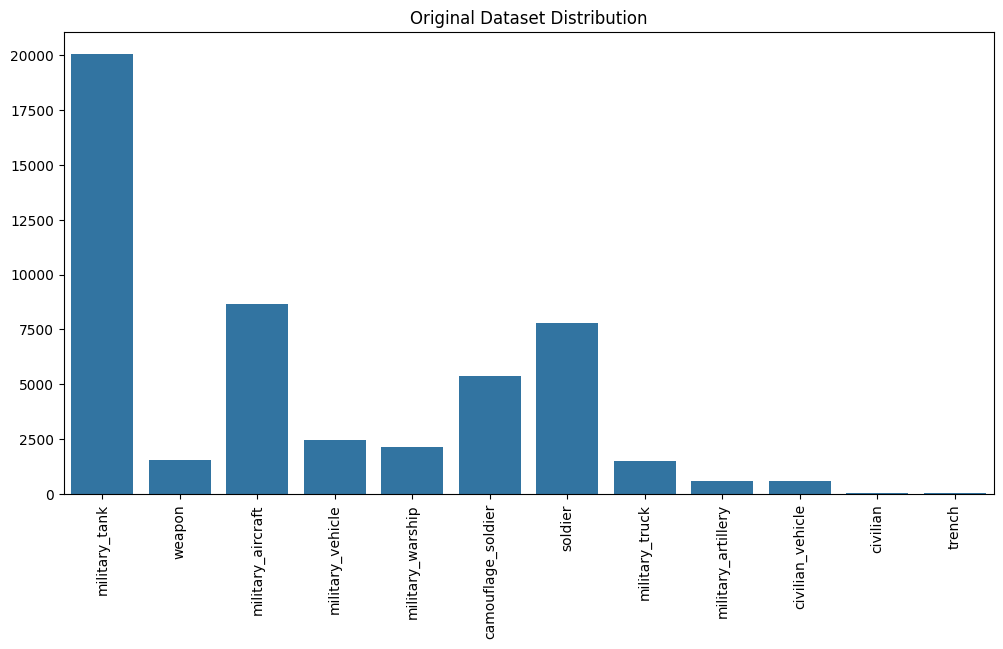

In [8]:
plt.figure(figsize=(12,6))

names = [class_names[k] for k in class_counter.keys()]
counts = list(class_counter.values())

sns.barplot(x=names, y=counts)

plt.xticks(rotation=90)
plt.title("Original Dataset Distribution")
plt.show()

# Step 9: Remove Unwanted Classes

Classes removed:

- civilian
- trench

After removal, labels will be remapped.

In [9]:
mapping = {
    0:0,
    1:1,
    2:2,
    3:3,
    4:4,
    6:5,
    7:6,
    8:7,
    10:8,
    11:9
}

remove_classes = [5, 9]

# Step 10: Create Clean Dataset

Create a new dataset after:

- Removing unwanted classes
- Removing empty labels
- Remapping class IDs

In [10]:
clean_path = Path("/kaggle/working/clean_dataset")

for split in ["train","val","test"]:
    (clean_path/f"{split}/images").mkdir(parents=True, exist_ok=True)
    (clean_path/f"{split}/labels").mkdir(parents=True, exist_ok=True)

# Step 11: Clean Dataset and Remap Labels

In [11]:
for split in ["train","val","test"]:

    img_folder = dataset_path/f"{split}/images"
    lbl_folder = dataset_path/f"{split}/labels"

    for lbl in lbl_folder.glob("*.txt"):

        new_lines = []

        with open(lbl, "r") as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            if len(parts)==0:
                continue

            cls = int(parts[0])

            if cls in remove_classes:
                continue

            if cls in mapping:
                parts[0] = str(mapping[cls])
                new_lines.append(" ".join(parts))

        if len(new_lines)==0:
            continue

        img = img_folder/f"{lbl.stem}.jpg"

        if not img.exists():
            img = img_folder/f"{lbl.stem}.png"

        shutil.copy(img, clean_path/f"{split}/images"/img.name)

        with open(clean_path/f"{split}/labels"/lbl.name,"w") as f:
            f.write("\n".join(new_lines))

# Step 12: Combine All Cleaned Data

After cleaning and remapping, combine all images and labels
from train, validation and test folders into a single dataset.

This ensures proper balancing before final splitting.

In [12]:
combined_path = Path("/kaggle/working/combined_dataset")

(combined_path/"images").mkdir(parents=True, exist_ok=True)
(combined_path/"labels").mkdir(parents=True, exist_ok=True)

for split in ["train", "val", "test"]:

    img_folder = clean_path/f"{split}/images"
    lbl_folder = clean_path/f"{split}/labels"

    for img_file in img_folder.iterdir():
        shutil.copy(img_file, combined_path/"images"/img_file.name)

    for lbl_file in lbl_folder.iterdir():
        shutil.copy(lbl_file, combined_path/"labels"/lbl_file.name)

print("Combined dataset created successfully.")

Combined dataset created successfully.


# Step 13: Group Images by Class

For balancing, group images according to their primary class.

In [13]:
class_images = defaultdict(list)

for lbl_file in (combined_path/"labels").glob("*.txt"):

    with open(lbl_file, "r") as f:
        lines = f.readlines()

    if len(lines) == 0:
        continue

    classes = [int(line.split()[0]) for line in lines]

    # Primary class = most frequent class in image
    main_class = Counter(classes).most_common(1)[0][0]

    class_images[main_class].append(lbl_file.stem)

for cls, imgs in class_images.items():
    print(f"Class {cls}: {len(imgs)} images")

Class 1: 782 images
Class 2: 9420 images
Class 0: 4099 images
Class 4: 834 images
Class 8: 4724 images
Class 5: 2962 images
Class 9: 1837 images
Class 3: 532 images
Class 7: 324 images
Class 6: 96 images


# Step 14: Balance Dataset

Keep a maximum number of images per class.

If a class has fewer images, keep all images.

In [14]:
limits = {
    0:300,
    1:300,
    2:300,
    3:300,
    4:300,
    5:300,
    6:228,
    7:293,
    8:300,
    9:300
}

selected_images = []

for cls, imgs in class_images.items():

    max_limit = limits.get(cls, 300)

    if len(imgs) > max_limit:
        imgs = random.sample(imgs, max_limit)

    selected_images.extend(imgs)

print("Total selected images:", len(selected_images))

Total selected images: 2789


# Step 15: Split Balanced Dataset

Split the balanced dataset into:

- Train → 70%
- Validation → 20%
- Test → 10%

In [15]:
random.shuffle(selected_images)

n = len(selected_images)

train_end = int(0.7 * n)
val_end = int(0.9 * n)

train_imgs = selected_images[:train_end]
val_imgs = selected_images[train_end:val_end]
test_imgs = selected_images[val_end:]

print("Train:", len(train_imgs))
print("Val:", len(val_imgs))
print("Test:", len(test_imgs))

Train: 1952
Val: 558
Test: 279


# Step 16: Create Final Dataset Structure

Create folders for final train, validation and test datasets.

In [16]:
final_dataset = Path("/kaggle/working/final_dataset")

for split in ["train", "val", "test"]:
    (final_dataset/f"{split}/images").mkdir(parents=True, exist_ok=True)
    (final_dataset/f"{split}/labels").mkdir(parents=True, exist_ok=True)

print("Folders created.")

Folders created.


# Step 17: Copy Files into Final Dataset

Copy images and labels into their respective splits.

In [17]:
def copy_files(file_list, split):

    for file_id in file_list:

        img_path = None

        for ext in [".jpg", ".jpeg", ".png"]:
            p = combined_path/"images"/f"{file_id}{ext}"

            if p.exists():
                img_path = p
                break

        lbl_path = combined_path/"labels"/f"{file_id}.txt"

        if img_path and lbl_path.exists():
            shutil.copy(img_path,
                        final_dataset/f"{split}/images"/img_path.name)

            shutil.copy(lbl_path,
                        final_dataset/f"{split}/labels"/lbl_path.name)


copy_files(train_imgs, "train")
copy_files(val_imgs, "val")
copy_files(test_imgs, "test")

print("Final dataset created successfully.")

Final dataset created successfully.


# Step 18: Verify Final Distribution

Check class distribution in train, validation and test datasets.

In [18]:
def check_distribution(label_folder):

    counter = Counter()

    for lbl in label_folder.glob("*.txt"):

        with open(lbl, "r") as f:
            lines = f.readlines()

        for line in lines:
            cls = int(line.split()[0])
            counter[cls] += 1

    return counter


for split in ["train", "val", "test"]:

    print(f"\n===== {split.upper()} =====")

    dist = check_distribution(
        final_dataset/f"{split}/labels"
    )

    for cls, count in sorted(dist.items()):
        print(f"{cls}: {count}")


===== TRAIN =====
0: 298
1: 373
2: 585
3: 593
4: 549
5: 580
6: 261
7: 350
8: 404
9: 246

===== VAL =====
0: 85
1: 90
2: 172
3: 153
4: 135
5: 182
6: 110
7: 91
8: 95
9: 78

===== TEST =====
0: 22
1: 29
2: 106
3: 83
4: 80
5: 94
6: 80
7: 50
8: 59
9: 32


# Step 19: Create Final YAML File

Create the final YAML configuration file for YOLOv8 training.

In [19]:
final_yaml = {
    "path": "/kaggle/working/final_dataset",

    "train": "train/images",
    "val": "val/images",
    "test": "test/images",

    "nc": 10,

    "names": {
        0: "camouflage_soldier",
        1: "weapon",
        2: "military_tank",
        3: "military_truck",
        4: "military_vehicle",
        5: "soldier",
        6: "civilian_vehicle",
        7: "military_artillery",
        8: "military_aircraft",
        9: "military_warship"
    }
}

with open("/kaggle/working/final_dataset.yaml", "w") as f:
    yaml.dump(final_yaml, f)

print("✅ YAML file created successfully.")

✅ YAML file created successfully.


# Step 20: Verify YAML File

Check whether the YAML file has been created correctly.

In [20]:
with open("/kaggle/working/final_dataset.yaml", "r") as f:
    print(f.read())

names:
  0: camouflage_soldier
  1: weapon
  2: military_tank
  3: military_truck
  4: military_vehicle
  5: soldier
  6: civilian_vehicle
  7: military_artillery
  8: military_aircraft
  9: military_warship
nc: 10
path: /kaggle/working/final_dataset
test: test/images
train: train/images
val: val/images



# Step 21: Install Ultralytics

Install the YOLOv8 library.

In [21]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 37.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 725.1 kB/s eta 0:00:00


# Step 22: Import YOLO and Load Pretrained Model

Load YOLOv8m pretrained weights.

In [22]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Step 23: Train YOLOv8 Model

Train YOLOv8 on the balanced military dataset.

In [23]:
results = model.train(
    data="/kaggle/working/final_dataset.yaml",

    epochs=100,
    imgsz=800,
    batch=16,

    optimizer="AdamW",
    lr0=0.0005,

    patience=20,

    cache=True,
    amp=True,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,

    mosaic=1.0,
    mixup=0.2,

    project="military_detection",
    name="yolov8m_final",

    exist_ok=True
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/final_dataset.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=

# Step 24: Validate Model

Evaluate the trained model on validation data.

In [24]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 93 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1843.9±518.0 MB/s, size: 142.3 KB)
val: Scanning /kaggle/working/final_dataset/val/labels.cache... 558 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 558/558 212.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 1.7it/s 20.3s
                   all        558       1191      0.787      0.686      0.738      0.509
    camouflage_soldier         60         85      0.706      0.506      0.609      0.285
                weapon         60         90      0.804      0.685      0.806      0.547
         military_tank         94        172       0.76      0.733      0.742      0.484
        military_truck         75        153      0.829       0.76      0.809      0.591
      military_vehicle         69

# Step 25: Evaluate on Test Dataset

Run evaluation on the test set.

In [25]:
best_model = YOLO(
    "/kaggle/working/runs/detect/military_detection/yolov8m_final/weights/best.pt"
)

test_metrics = best_model.val(
    data="/kaggle/working/final_dataset.yaml",
    split="test"
)

print(test_metrics)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 93 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1435.3±1182.8 MB/s, size: 140.0 KB)
val: Scanning /kaggle/working/final_dataset/test/labels... 279 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 279/279 1.3Kit/s 0.2s
val: New cache created: /kaggle/working/final_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.7it/s 10.6s
                   all        279        635      0.798      0.653      0.741      0.508
    camouflage_soldier         19         22      0.711      0.559      0.694      0.447
                weapon         23         29      0.805      0.793      0.873      0.631
         military_tank         60        106      0.761      0.547      0.656      0.456
        military_truck         40         83      0.897 

# Step 26: Display Training Results

Display result graphs generated during training.

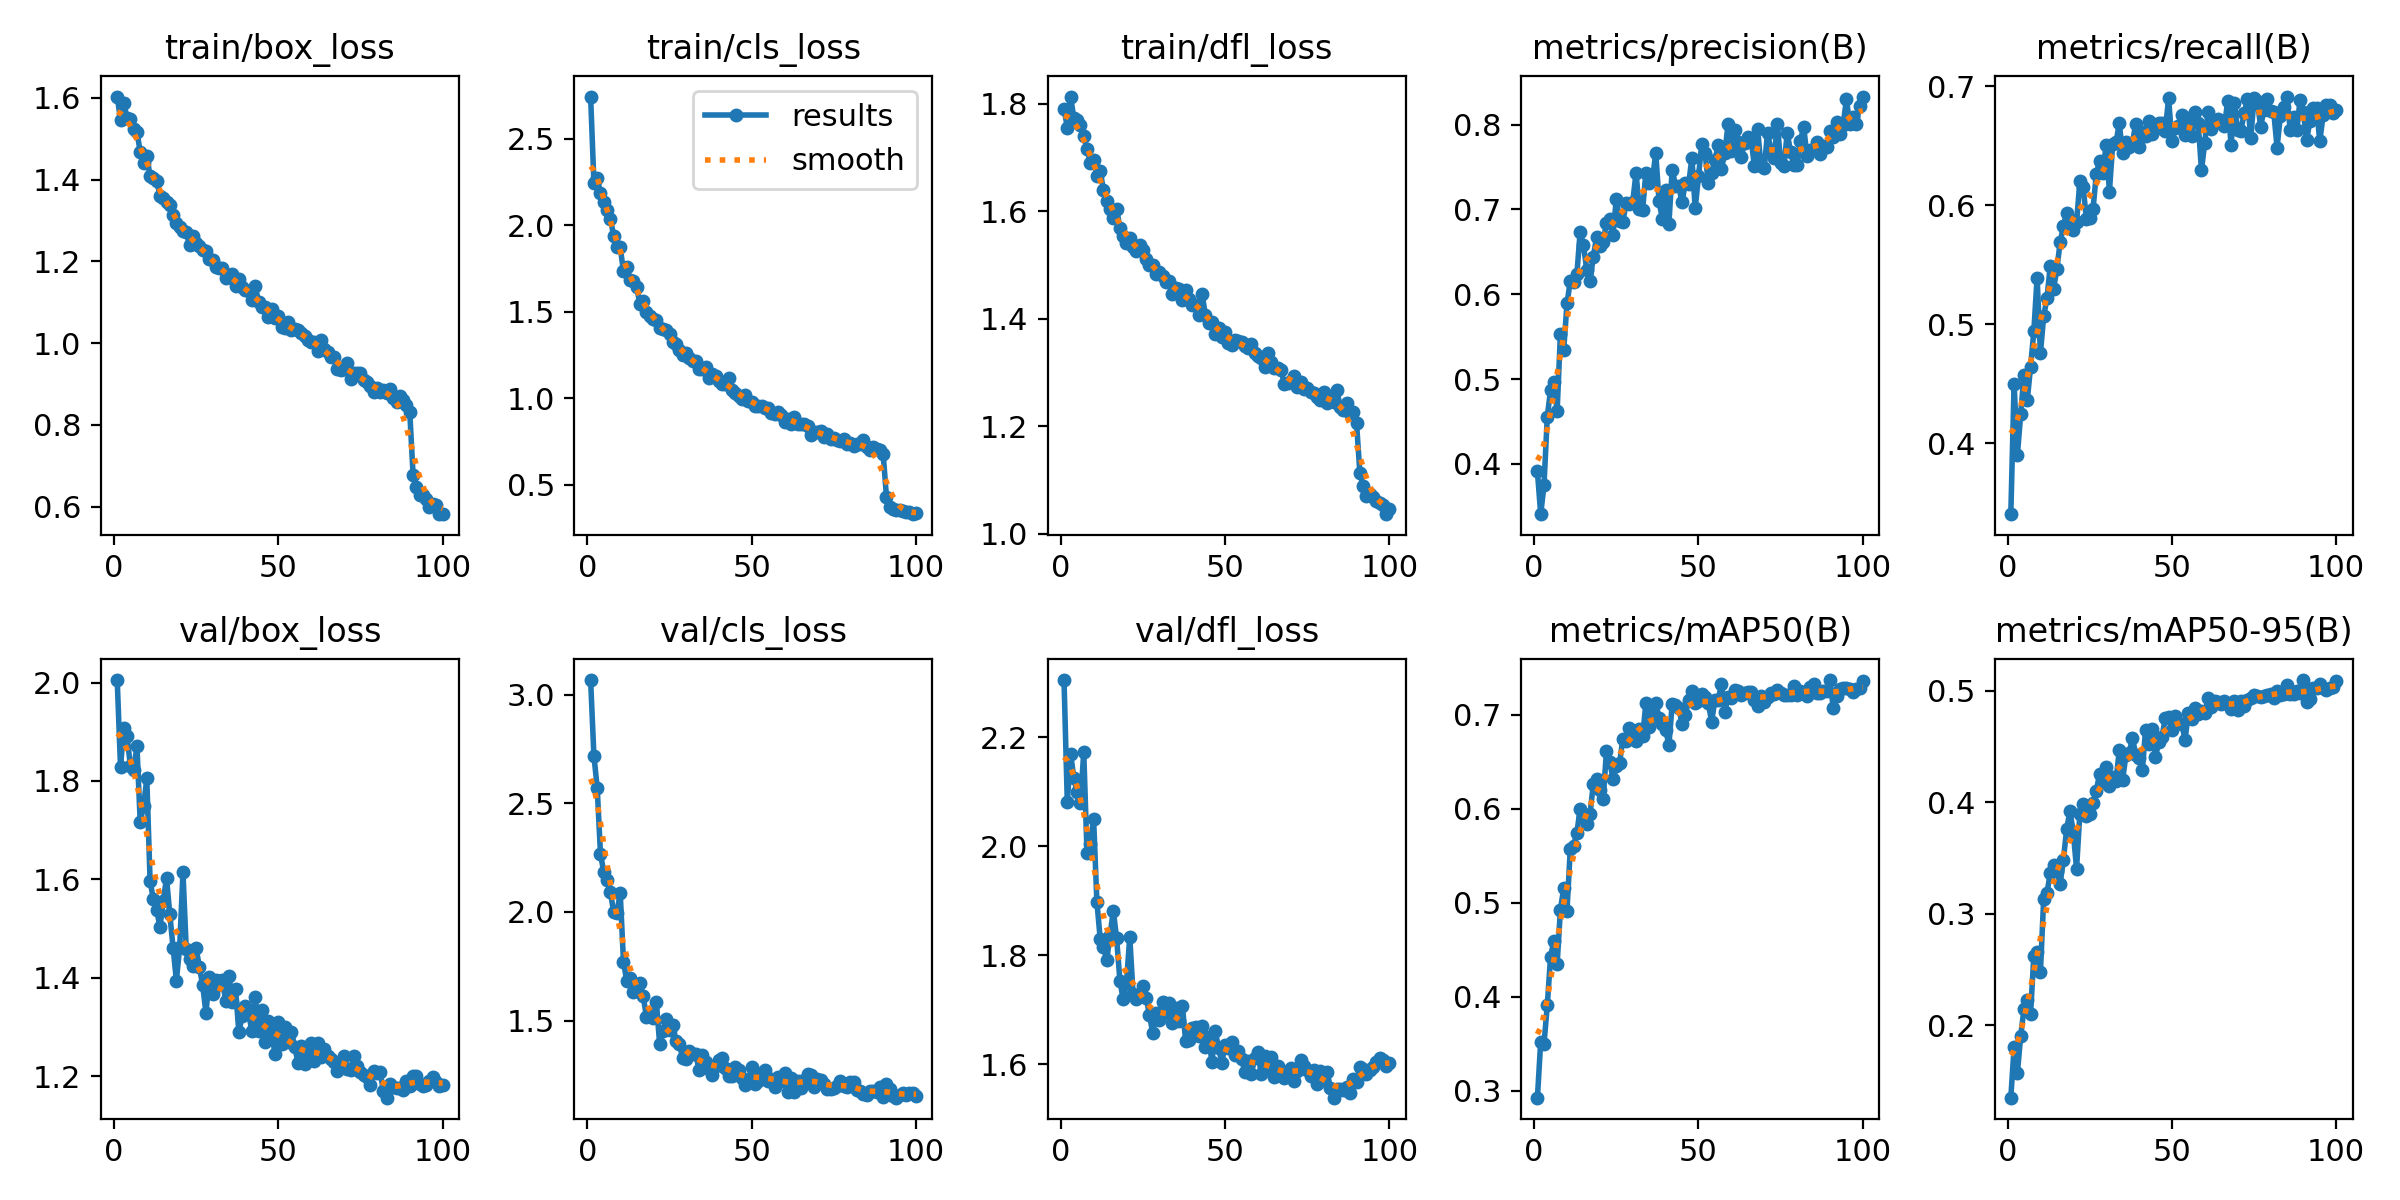

In [26]:
from IPython.display import Image, display

display(
    Image(
        filename="/kaggle/working/runs/detect/military_detection/yolov8m_final/results.png"
    )
)

# Step 27: Display Confusion Matrix

Analyze class-wise confusion.

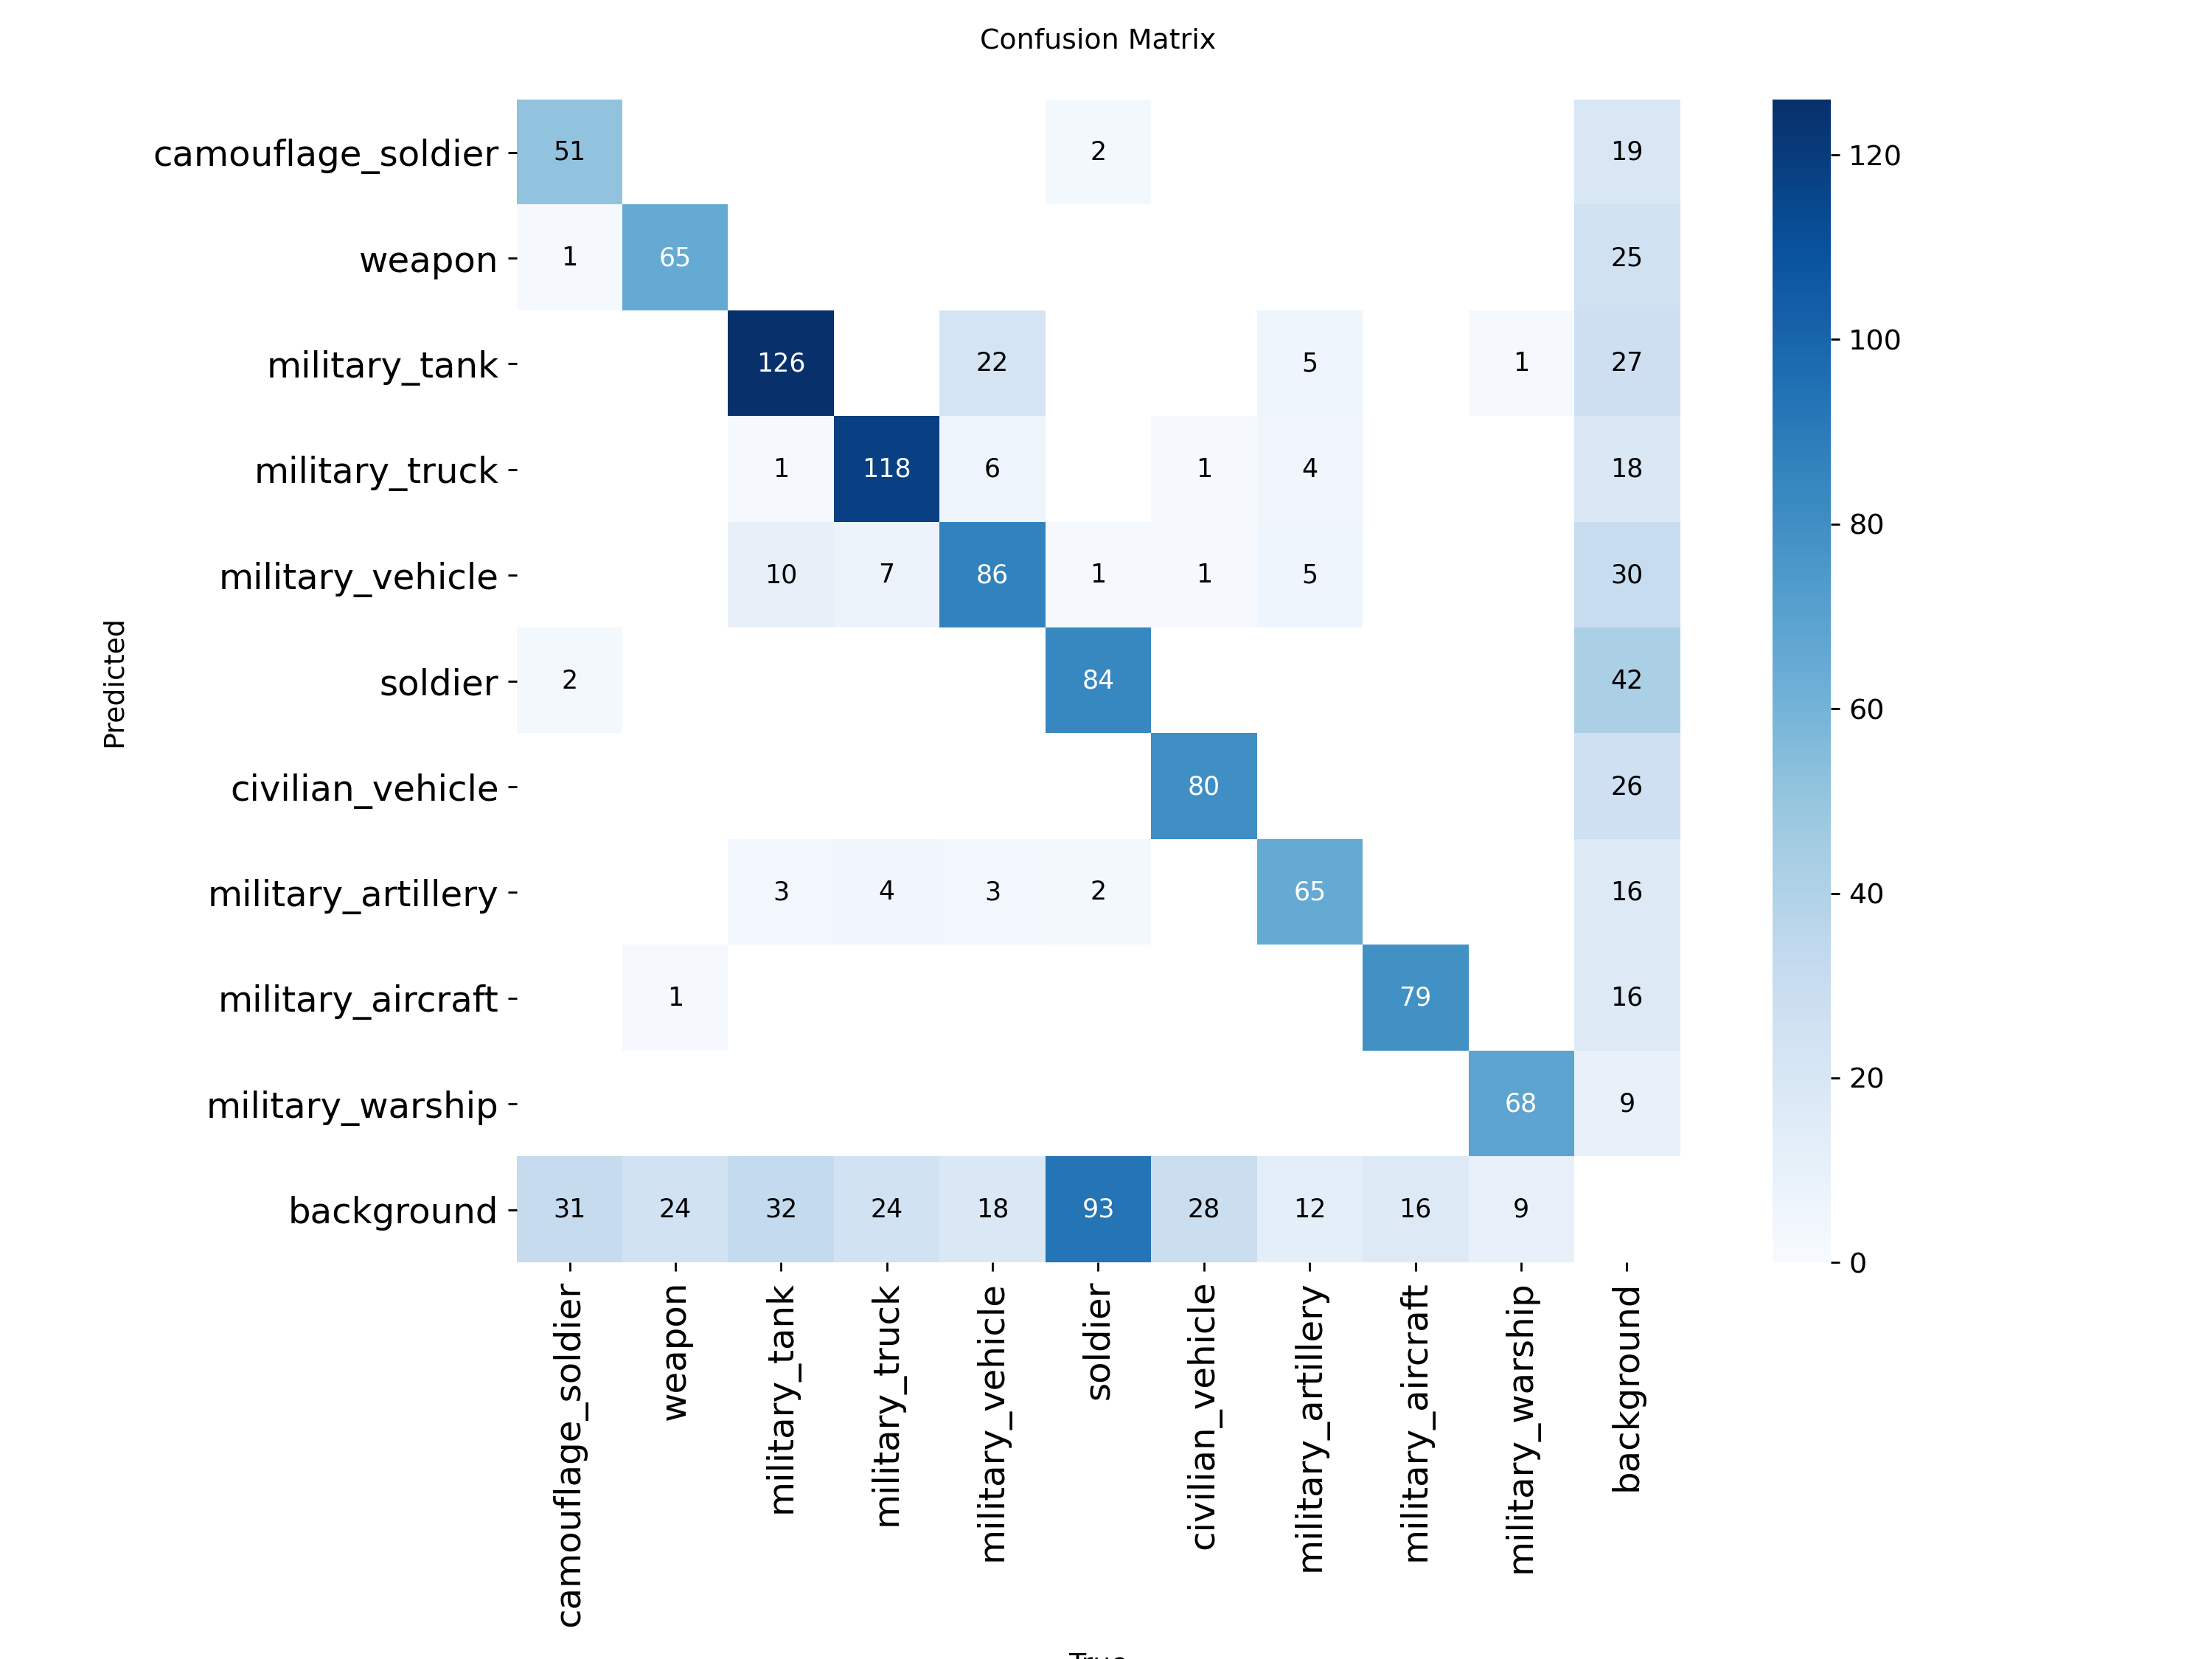

In [27]:
from IPython.display import Image, display

display(
    Image(
        filename="/kaggle/working/runs/detect/military_detection/yolov8m_final/confusion_matrix.png"
    )
)

# Military Object Detection using YOLOv8 - Project Summary

## Objective

The objective of this project is to build a robust Military Object Detection system using YOLOv8 by performing dataset cleaning, preprocessing, balancing, training, and evaluation.

---

## Workflow Overview

### 1. Dataset Exploration

- Verify dataset structure.
- Check train, validation, and test folders.
- Load dataset configuration.

---

### 2. Exploratory Data Analysis (EDA)

- Count total images.
- Count object instances per class.
- Analyze class imbalance.
- Visualize class distribution using bar plots.

---

### 3. Dataset Cleaning

The dataset is cleaned by:

- Removing empty label files.
- Removing unwanted classes:
  - `civilian`
  - `trench`

Reason:

These classes are not useful for military object detection and may negatively affect model performance.

---

### 4. Label Remapping

After removing classes, class IDs are remapped to maintain continuous indexing required by YOLO.

Example:

| Old ID | New ID |
|--------|--------|
| 0 | 0 |
| 1 | 1 |
| 2 | 2 |
| 3 | 3 |
| 4 | 4 |
| 6 | 5 |
| 7 | 6 |
| 8 | 7 |
| 10 | 8 |
| 11 | 9 |

Final number of classes:

**10 Classes**

---

### 5. Dataset Balancing

To reduce class imbalance:

- Images from all splits are combined.
- Images are grouped class-wise.
- Maximum image limits are applied.

This helps improve:

- Generalization
- Precision
- Recall
- Confusion Matrix quality

---

### 6. Final Dataset Split

The balanced dataset is split into:

| Split | Ratio |
|--------|-------|
| Train | 70% |
| Validation | 20% |
| Test | 10% |

This ensures every class is represented in all splits.

---

### 7. YOLOv8 Training

Model used:

```text
yolov8m.pt
```

Training includes:

- Data augmentation
- Mosaic augmentation
- MixUp augmentation
- AdamW optimizer
- Early stopping

---

### 8. Model Evaluation

Model performance is evaluated using:

- Precision
- Recall
- mAP@50
- mAP@50-95

Generated evaluation artifacts:

- Confusion Matrix
- PR Curve
- F1 Curve
- Loss Curves

---

### 9. Real World Testing

The trained model can be used for:

- Image inference
- Video inference
- Real-time webcam detection

---

## Final Military Classes

```text
0  camouflage_soldier
1  weapon
2  military_tank
3  military_truck
4  military_vehicle
5  soldier
6  civilian_vehicle
7  military_artillery
8  military_aircraft
9  military_warship
```

---

## Final Pipeline

```text
Raw Dataset
      ↓
Dataset Exploration
      ↓
EDA
      ↓
Remove Empty Labels
      ↓
Remove Unwanted Classes
      ↓
Remap Labels
      ↓
Combine Dataset
      ↓
Balance Dataset
      ↓
Train/Validation/Test Split
      ↓
Create YAML File
      ↓
Train YOLOv8
      ↓
Evaluate Model
      ↓
Analyze Results
      ↓
Real World Testing
```

## Conclusion

A balanced and cleaned dataset significantly improves object detection performance. The proposed workflow follows industry-standard practices for building a reliable Military Object Detection system using YOLOv8.